# VargBot Playground — build MSMEMate's ONDC domain classifier yourself

This notebook reproduces, end to end, the **VargBot v2** domain classifier that runs in production at [msmemate.com](https://www.msmemate.com) — the model that maps an Indian MSE's business description (English / Hinglish) to one of the **14 ONDC retail domains**.

You get the **same 33.5K-row training corpus**, the same architecture, and every performance calculation we publish: 5-fold cross-validation, held-out test metrics, per-domain precision/recall/F1, the confusion matrix, the honest per-source breakdown, and the confidence-gate calibration.

**Data sources** (each row carries its `source` for lineage):

| source | rows | what it is |
|---|---|---|
| flipkart | ~17K | real product listings (PromptCloudHQ 20K, CC BY-SA 4.0) |
| mepma | ~7.6K | real SHG-seller product names, MEPMA Andhra Pradesh |
| mse_profile | ~4.7K | real-derived MSE profiles with Hinglish descriptions |
| synthetic | ~4.1K | template text for the 6 domains nothing else covered |

> **Honesty note (read this first):** template-generated rows have near-duplicate twins on both sides of any random split, which inflates their scores. That's why we compute a **real-products-only** metric below — that is the number to trust. More: [our MLOps playbook](https://www.msmemate.com/blog/mlops-honest-ai-lifecycle).

In [1]:
# Setup — everything here is preinstalled on Colab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import FeatureUnion, Pipeline

SEED = 20260708           # same seed as production training
QUICK = False             # set True to skip the 5-fold CV (saves ~5 min on Colab CPU)
BLUE, SAFFRON, RED, GRAY, INK = "#1B4FCC", "#E8680C", "#B42318", "#9EA5BE", "#0B1437"

## The serving architecture you are about to rebuild

The trained model is the **first layer of a chain**. It only answers when confident; everything else routes onward — and every result is stamped with the engine that produced it.

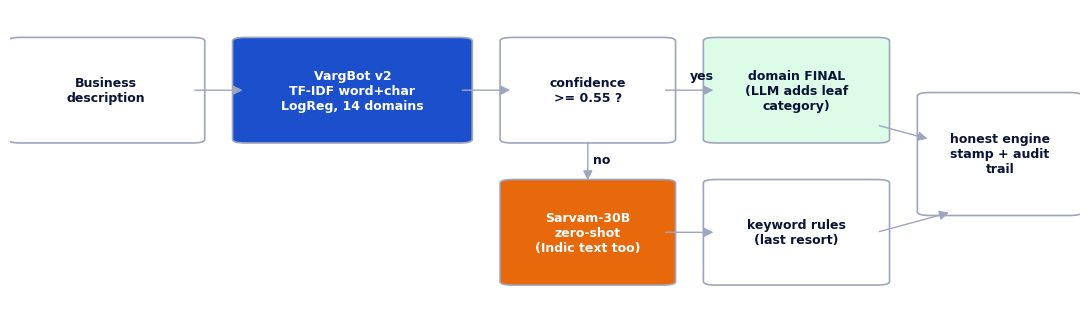

In [2]:
# Architecture diagram (drawn, not imported — tweak it as you experiment)
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis("off")
boxes = [
    (0.01, "Business\ndescription", "#FFFFFF", INK),
    (0.22, "VargBot v2\nTF-IDF word+char\n+ LogReg (14 domains)", BLUE, "w"),
    (0.47, "confidence\n>= 0.55 ?", "#FFFFFF", INK),
    (0.66, "domain FINAL\nLLM picks leaf\ncategory", "#dcfce7", INK),
    (0.66, None, None, None),
]
def box(x, y, w, h, text, fc, tc):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.012",
                                fc=fc, ec=GRAY, lw=1.2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=9,
            color=tc, fontweight="bold")
box(0.01, 0.55, 0.16, 0.34, "Business\ndescription", "#FFFFFF", INK)
box(0.22, 0.55, 0.20, 0.34, "VargBot v2\nTF-IDF word+char\nLogReg, 14 domains", BLUE, "w")
box(0.47, 0.55, 0.14, 0.34, "confidence\n>= 0.55 ?", "#FFFFFF", INK)
box(0.66, 0.55, 0.15, 0.34, "domain FINAL\n(LLM adds leaf\ncategory)", "#dcfce7", INK)
box(0.47, 0.06, 0.14, 0.34, "Sarvam-30B\nzero-shot\n(Indic text too)", SAFFRON, "w")
box(0.66, 0.06, 0.15, 0.34, "keyword rules\n(last resort)", "#FFFFFF", INK)
box(0.86, 0.30, 0.13, 0.40, "honest engine\nstamp + audit\ntrail", "#FFFFFF", INK)
for a, b, y1, y2 in [(0.17, 0.22, 0.72, 0.72), (0.42, 0.47, 0.72, 0.72),
                     (0.61, 0.66, 0.72, 0.72), (0.81, 0.86, 0.60, 0.55)]:
    ax.add_patch(FancyArrowPatch((a, y1), (b, y2), arrowstyle="-|>", mutation_scale=14, color=GRAY))
ax.add_patch(FancyArrowPatch((0.54, 0.55), (0.54, 0.40), arrowstyle="-|>", mutation_scale=14, color=GRAY))
ax.add_patch(FancyArrowPatch((0.61, 0.23), (0.66, 0.23), arrowstyle="-|>", mutation_scale=14, color=GRAY))
ax.add_patch(FancyArrowPatch((0.81, 0.23), (0.88, 0.30), arrowstyle="-|>", mutation_scale=14, color=GRAY))
ax.text(0.635, 0.76, "yes", fontsize=9, color=INK, fontweight="bold")
ax.text(0.545, 0.47, "no", fontsize=9, color=INK, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); plt.tight_layout(); plt.show()

In [3]:
# 1) Load the corpus straight from the public repo (~8 MB)
df = pd.read_csv("https://raw.githubusercontent.com/Aakashdeep-Srivastava/indiaAI-agentMap/main/data/processed/training_corpus_v2.csv")
print(df.shape)
df.sample(5, random_state=SEED)

(33529, 3)


,text,ondc_domain,source
21799,Silver Kalash with Coconut for Pooja (4 inch)....,RET16,mepma
24730,Samyak Textiles is a micro enterprise producin...,RET12,mse_profile
28380,We manufacture handbags and kurtis in Janjgir-...,RET12,mse_profile
23811,The SEO optimized title is:**Jute tote bag wit...,RET16,mepma
25314,Humari unit kurtis banati hai. 3 saal se yeh k...,RET12,mse_profile


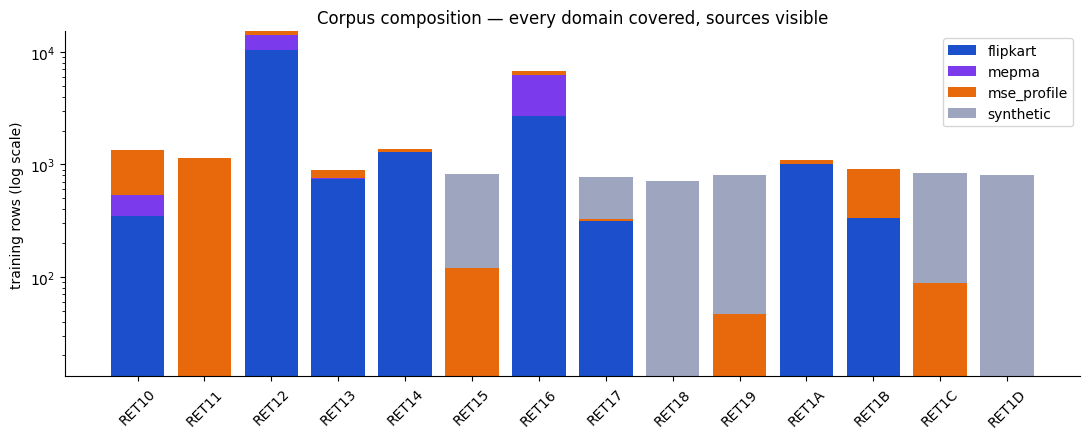

source,flipkart,mepma,mse_profile,synthetic,total
ondc_domain,,,,,
RET10,351,178,825,0,1354
RET11,0,0,1140,0,1140
RET12,10305,3869,1073,0,15247
RET13,741,15,143,0,899
RET14,1294,0,73,0,1367
RET15,0,0,119,700,819
RET16,2716,3551,516,0,6783
RET17,317,0,11,450,778
RET18,0,0,13,700,713


In [4]:
# 2) Explore the data — rows per domain, split by source
DOMAIN_NAMES = {
    "RET10": "Grocery", "RET11": "F&B", "RET12": "Fashion", "RET13": "Beauty & Personal Care",
    "RET14": "Electronics", "RET15": "Appliances", "RET16": "Home & Decor", "RET17": "Toys & Games",
    "RET18": "Health & Wellness", "RET19": "Pharma", "RET1A": "Auto Components",
    "RET1B": "Hardware & Industrial", "RET1C": "Building & Construction", "RET1D": "Chemicals",
}
pivot = df.pivot_table(index="ondc_domain", columns="source", aggfunc="size", fill_value=0)
pivot = pivot.reindex(sorted(pivot.index))
fig, ax = plt.subplots(figsize=(11, 4.5))
bottom = np.zeros(len(pivot))
colors = {"flipkart": BLUE, "mepma": "#7C3AED", "mse_profile": SAFFRON, "synthetic": GRAY}
for source_name in ["flipkart", "mepma", "mse_profile", "synthetic"]:
    if source_name in pivot.columns:
        vals = pivot[source_name].values
        ax.bar(pivot.index, vals, bottom=bottom, label=source_name, color=colors[source_name])
        bottom += vals
ax.set_yscale("log"); ax.set_ylabel("training rows (log scale)")
ax.set_title("Corpus composition — every domain covered, sources visible")
ax.legend(); ax.tick_params(axis="x", rotation=45)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()
pivot.assign(total=pivot.sum(axis=1))

In [5]:
# 3) The exact production split: stratified 80/10/10
idx = np.arange(len(df))
labels = df["ondc_domain"].tolist()
idx_tr, idx_tmp = train_test_split(idx, test_size=0.2, random_state=SEED,
                                   stratify=[labels[i] for i in idx])
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5, random_state=SEED,
                                   stratify=[labels[i] for i in idx_tmp])
X = df["text"].tolist(); y = labels; src = df["source"].tolist()
take = lambda ids: ([X[i] for i in ids], [y[i] for i in ids], [src[i] for i in ids])
X_tr, y_tr, _ = take(idx_tr); X_val, y_val, _ = take(idx_val); X_te, y_te, s_te = take(idx_te)
print(f"train {len(X_tr)} / val {len(X_val)} / test {len(X_te)}")

train 26823 / val 3353 / test 3353


In [6]:
# 4) Train the v2 architecture (~2 min on Colab CPU)
def make_pipe(C=2.0):
    return Pipeline([
        ("tfidf", FeatureUnion([
            ("word", TfidfVectorizer(ngram_range=(1, 2), max_features=120_000,
                                     sublinear_tf=True, min_df=2)),
            ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                     max_features=80_000, sublinear_tf=True, min_df=2)),
        ])),
        ("clf", LogisticRegression(C=C, max_iter=2000, class_weight="balanced")),
    ])

model = make_pipe()
model.fit(X_tr + X_val, y_tr + y_val)   # final fit on train+val, exactly like production
print("trained on", len(X_tr) + len(X_val), "rows,", len(model.classes_), "domains")

trained on 30176 rows, 14 domains


In [7]:
# 5) Model stability — 5-fold cross-validation (production: 0.9841 +/- 0.0010)
if not QUICK:
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    scores = cross_val_score(make_pipe(), X_tr + X_val, y_tr + y_val, cv=cv, scoring="f1_macro")
    print("fold scores:", scores.round(4))
    print(f"5-fold CV macro-F1: {scores.mean():.4f} +/- {scores.std():.4f}")
else:
    print("QUICK=True - skipped (production reported 0.9841 +/- 0.0010)")

fold scores: [0.9826 0.9836 0.9842 0.9862 0.985 ]
5-fold CV macro-F1: 0.9843 +/- 0.0012


accuracy  : 0.9893   (production: 0.9893)
macro-F1  : 0.9866   (production: 0.9866)
micro-F1  : 0.9893


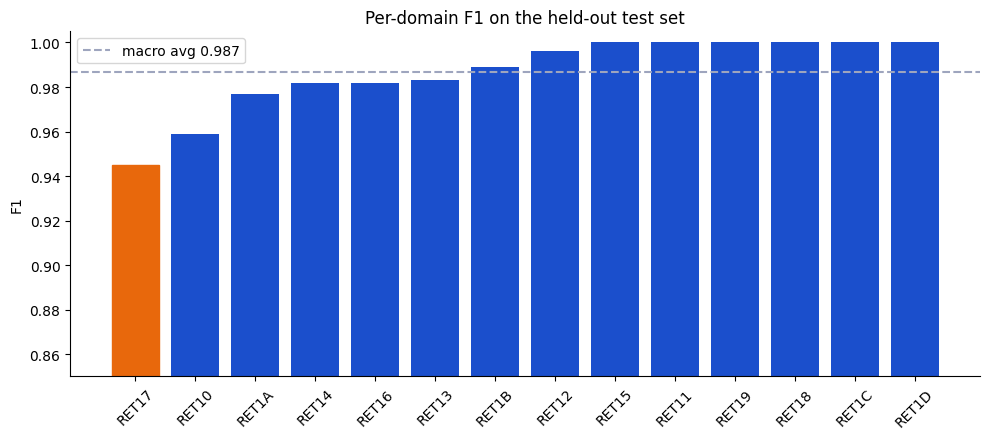

,domain,name,precision,recall,f1,support
7,RET17,Toys & Games,0.906,0.987,0.945,78
0,RET10,Grocery,0.963,0.956,0.959,135
10,RET1A,Auto Components,0.991,0.963,0.977,109
4,RET14,Electronics,0.971,0.993,0.982,137
6,RET16,Home & Decor,0.981,0.984,0.982,679
3,RET13,Beauty & Personal Care,0.978,0.989,0.983,90
11,RET1B,Hardware & Industrial,1.000,0.978,0.989,91
2,RET12,Fashion,0.998,0.993,0.996,1524
5,RET15,Appliances,1.000,1.000,1.000,82
1,RET11,F&B,1.000,1.000,1.000,114


In [8]:
# 6) Held-out test performance — every number we publish, recomputed by you
pred = model.predict(X_te)
print(f"accuracy  : {accuracy_score(y_te, pred):.4f}   (production: 0.9893)")
print(f"macro-F1  : {f1_score(y_te, pred, average='macro'):.4f}   (production: 0.9866)")
print(f"micro-F1  : {f1_score(y_te, pred, average='micro'):.4f}")

classes = sorted(set(y_te))
p, r, f1v, sup = precision_recall_fscore_support(y_te, pred, labels=classes, zero_division=0)
perf = pd.DataFrame({"domain": classes,
                     "name": [DOMAIN_NAMES.get(c, c) for c in classes],
                     "precision": p.round(3), "recall": r.round(3),
                     "f1": f1v.round(3), "support": sup}).sort_values("f1")

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(perf["domain"], perf["f1"], color=BLUE)
bars[0].set_color(SAFFRON)   # weakest domain highlighted
ax.axhline(perf["f1"].mean(), color=GRAY, linestyle="--", label=f"macro avg {perf['f1'].mean():.3f}")
ax.set_ylim(0.85, 1.005); ax.set_ylabel("F1"); ax.set_title("Per-domain F1 on the held-out test set")
ax.legend(); ax.tick_params(axis="x", rotation=45)
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()
perf

In [9]:
# 7) THE HONEST NUMBER — performance on real product text only
s_arr, y_arr, p_arr = np.array(s_te), np.array(y_te), np.array(pred)
rows = []
for source_name in sorted(set(s_te)):
    m = s_arr == source_name
    rows.append({"source": source_name, "n": int(m.sum()),
                 "accuracy": round(float((p_arr[m] == y_arr[m]).mean()), 4)})
display(pd.DataFrame(rows))
real = np.isin(s_arr, ["flipkart", "mepma"])
print(f"REAL-PRODUCTS-ONLY: accuracy {(p_arr[real] == y_arr[real]).mean():.4f}, "
      f"macro-F1 {f1_score(y_arr[real], p_arr[real], average='macro'):.4f}  (production: 0.9854 / 0.9575)")
print("Template rows (mse_profile, synthetic) score ~100% because near-duplicate")
print("templates land on both sides of the split — that is why this number matters.")

,source,n,accuracy
0,flipkart,1667,0.9808
1,mepma,799,0.9950
2,mse_profile,470,1.0000
3,synthetic,417,1.0000


REAL-PRODUCTS-ONLY: accuracy 0.9854, macro-F1 0.9575  (production: 0.9854 / 0.9575)
Template rows (mse_profile, synthetic) score ~100% because near-duplicate
templates land on both sides of the split — that is why this number matters.


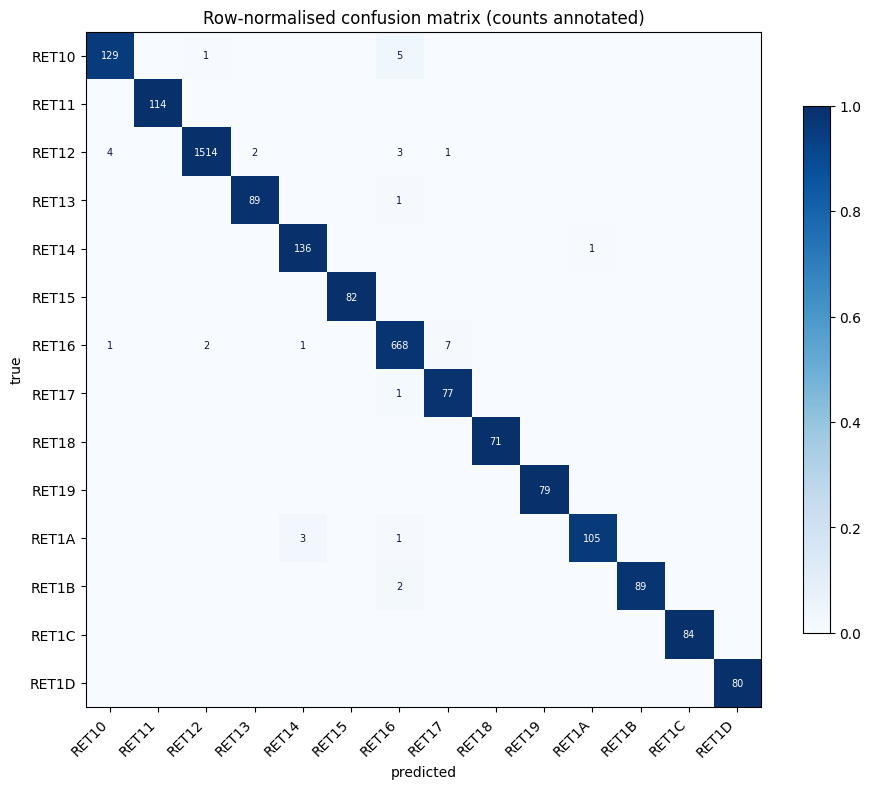

In [10]:
# 8) Confusion matrix — where do the mistakes actually go?
cm = confusion_matrix(y_te, pred, labels=classes)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes)), classes, rotation=45, ha="right")
ax.set_yticks(range(len(classes)), classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Row-normalised confusion matrix (counts annotated)")
for i in range(len(classes)):
    for j in range(len(classes)):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm_norm[i, j] > 0.5 else INK)
fig.colorbar(im, shrink=0.75); plt.tight_layout(); plt.show()

## Why do correct answers sometimes show "only" 0.6 confidence?

A class-balanced logistic regression over **14 classes** is deliberately conservative: probability mass is spread across every plausible domain, so 0.59 for the winner (vs a 7% random-chance floor) is a strong vote, not a weak one. What actually matters operationally is **precision at the gate** — the next cell computes it: when this model's top probability clears 0.55, how often is it right?

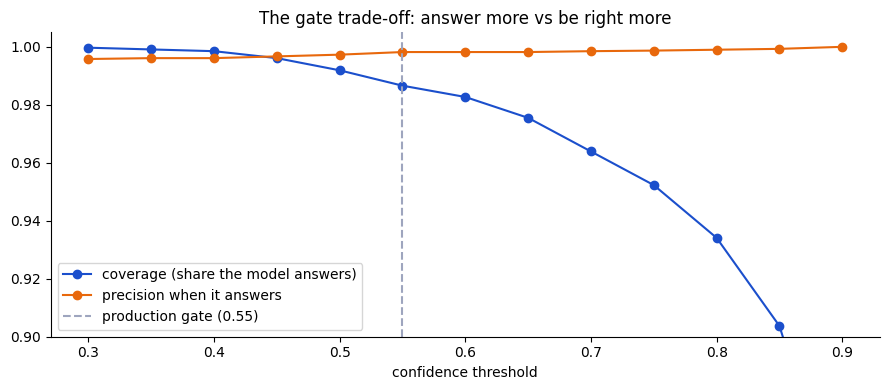

,threshold,coverage,precision_when_gated
0,0.30,0.9997,0.9958
1,0.35,0.9991,0.9961
2,0.40,0.9985,0.9961
3,0.45,0.9961,0.9967
4,0.50,0.9919,0.9973
5,0.55,0.9866,0.9982
6,0.60,0.9827,0.9982
7,0.65,0.9755,0.9982
8,0.70,0.9639,0.9985
9,0.75,0.9523,0.9987


In [11]:
# 9) Gate calibration — how the production gate (0.55) was chosen
val_proba = model.predict_proba(X_val)
val_pred = model.classes_[val_proba.argmax(axis=1)]
val_conf = val_proba.max(axis=1)
y_val_arr = np.array(y_val)
rows = []
for t in np.arange(0.30, 0.95, 0.05):
    m = val_conf >= t
    rows.append({"threshold": round(float(t), 2), "coverage": round(float(m.mean()), 4),
                 "precision_when_gated": round(float((val_pred[m] == y_val_arr[m]).mean()), 4) if m.any() else None})
gate = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(gate["threshold"], gate["coverage"], color=BLUE, marker="o", label="coverage (share the model answers)")
ax.plot(gate["threshold"], gate["precision_when_gated"], color=SAFFRON, marker="o", label="precision when it answers")
ax.axvline(0.55, color=GRAY, linestyle="--", label="production gate (0.55)")
ax.set_xlabel("confidence threshold"); ax.set_ylim(0.9, 1.005); ax.legend()
ax.set_title("The gate trade-off: answer more vs be right more")
for spine in ["top", "right"]: ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()
gate

In [12]:
# 10) PLAYGROUND — classify your own business description (Hinglish welcome!)
def classify(text, top=3):
    proba = model.predict_proba([text])[0]
    order = proba.argsort()[::-1][:top]
    print(f'"{text}"')
    for i in order:
        c = model.classes_[i]
        bar = "#" * int(proba[i] * 40)
        print(f"  {c} {DOMAIN_NAMES.get(c, ''):26s} {proba[i]:.3f} {bar}")
    verdict = "ANSWERS (above 0.55 gate)" if proba.max() >= 0.55 else "defers to the LLM chain (below gate)"
    print(f"  -> {verdict}\n")

classify("Hum Moradabad mein brass ke diye aur murtiyan banate hain")
classify("Cement bricks aur TMT bars ka wholesale karobar")
classify("Generic medicines and surgical supplies distributor")
classify("Fresh vegetables and kirana store")   # genuinely ambiguous -> below gate, by design
classify("YOUR BUSINESS DESCRIPTION HERE")

"Hum Moradabad mein brass ke diye aur murtiyan banate hain"
  RET18 Health & Wellness          0.194 #######
  RET16 Home & Decor               0.181 #######
  RET12 Fashion                    0.147 #####
  -> defers to the LLM chain (below gate)

"Cement bricks aur TMT bars ka wholesale karobar"
  RET1C Building & Construction    0.999 #######################################
  RET12 Fashion                    0.000 
  RET16 Home & Decor               0.000 
  -> ANSWERS (above 0.55 gate)

"Generic medicines and surgical supplies distributor"
  RET19 Pharma                     0.999 #######################################
  RET13 Beauty & Personal Care     0.000 
  RET18 Health & Wellness          0.000 
  -> ANSWERS (above 0.55 gate)

"Fresh vegetables and kirana store"
  RET16 Home & Decor               0.336 #############
  RET12 Fashion                    0.187 #######
  RET10 Grocery                    0.091 ###
  -> defers to the LLM chain (below gate)

"YOUR BUSINESS DESCRIPTION

## Your turn — can you beat 0.957 real-only macro-F1?

Ideas we would genuinely love to see:

1. **Better features** — different n-gram ranges, `max_features`, or a transliteration step so Devanagari input hits the trained model instead of deferring.
2. **Different models** — LinearSVC + calibration, SGD, or a small Indian transformer (MuRIL / IndicBERT) on the GPU runtime.
3. **Fix the weak spots** — RET17 (Toys) and RET10 (Grocery) have the lowest F1. Read their confusion-matrix rows: what are they mistaken for, and what data would fix it?
4. **Replace the synthetic rows** — the 6 synthetic-backed domains need real data. Know a public Indian product dataset for pharma, construction or chemicals? That is the single highest-value contribution.
5. **Per-domain gates** — one global 0.55 threshold is blunt; calibrate a gate per domain.

**Rules of the honest game:** never tune on the test split, always report the real-products-only number, and disclose anything synthetic.

---
*Data licensing: flipkart rows derive from the PromptCloudHQ Flipkart 20K dataset (CC BY-SA 4.0); the corpus is shared for research/education under the same terms. Built by Team XphoraAI for the IndiaAI Innovation Challenge 2026 — [msmemate.com](https://www.msmemate.com).*